In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
connection = sqlite3.connect('../../data/checking-logs.sqlite')
query = '''
WITH user_commits AS (
    SELECT
        uid,
        timestamp,
        COUNT(*) AS commits
    FROM 
        checker
    WHERE
        status = 'ready'
        AND uid LIKE 'user_%'
        AND labname = 'project1'
    GROUP BY
        uid,
        timestamp
)
SELECT
    uid,
    timestamp,
    commits,
    SUM(commits) OVER (
        PARTITION BY uid
        ORDER BY timestamp
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_commits
FROM 
    user_commits
ORDER BY
    uid,
    timestamp;'''
df = pd.read_sql(query, connection)
connection.close()
df['timestamp'] = pd.to_datetime(df['timestamp'])

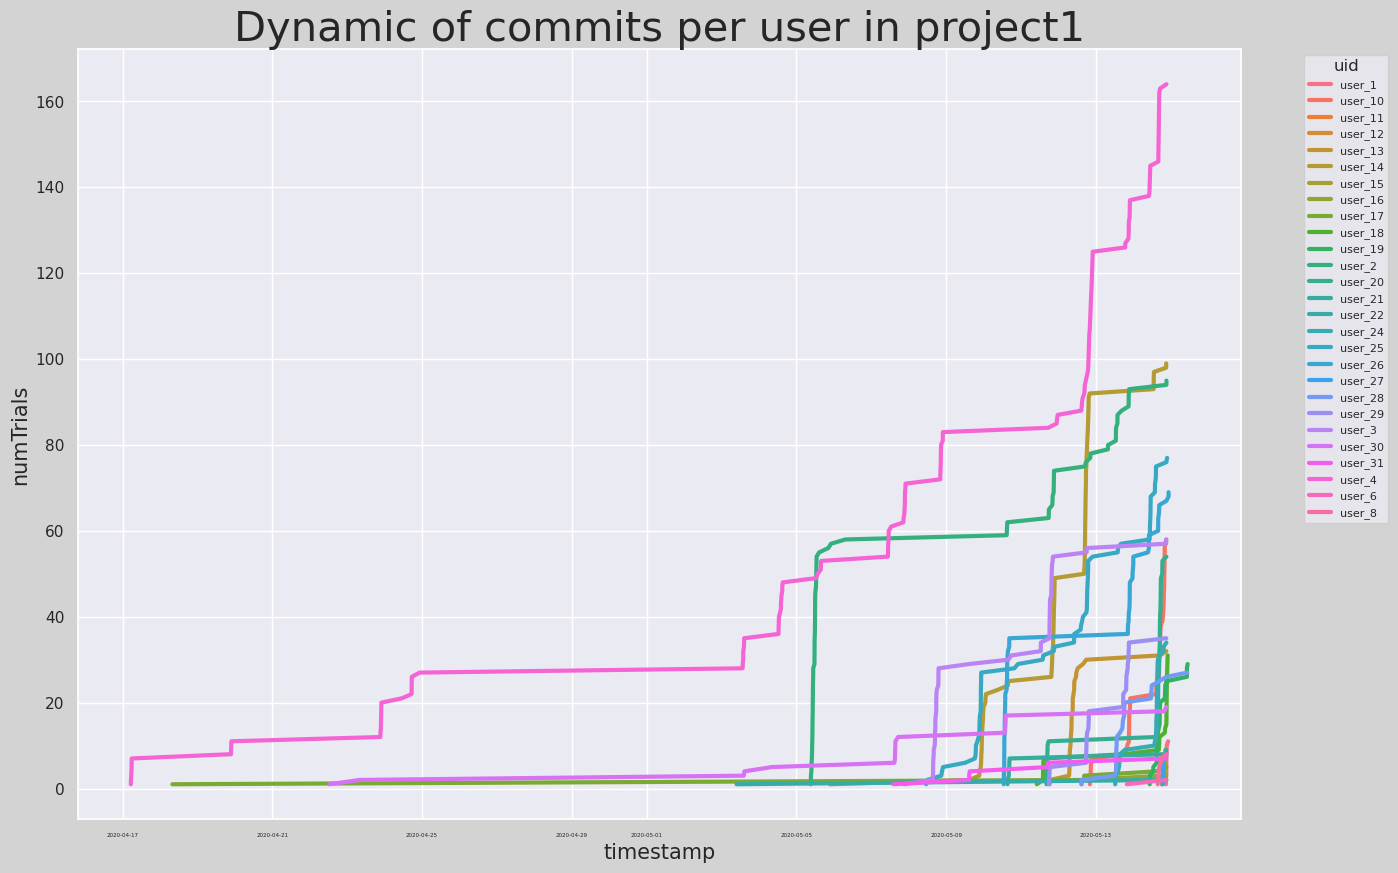

In [2]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15,10))
sns.lineplot(
    data=df,
    linewidth=3,
    x="timestamp",
    y="cumulative_commits",
    hue="uid",
    palette=sns.color_palette("husl", 27)
)
 
plt.title("Dynamic of commits per user in project1", fontsize=30)
plt.legend(title="uid", bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8})
plt.xlabel("timestamp", fontsize=15)
plt.ylabel("numTrials", fontsize=15)
plt.xticks(fontsize=4)
plt.gcf().set_facecolor('lightgray')

## Questions
“Which user was the leader in the number of commits almost all of the time?” The answer: user_4.

“Which user was the leader for only a short period of time?” The answer: user_2.